<a href="https://colab.research.google.com/github/dishxhub/CA3/blob/main/MRF_CA1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

year              3/1/2018  3/1/2019  3/1/2020  3/1/2021  3/1/2022  3/1/2023  \
equitycapital          839       839       839      1030      1030      1030   
Reserves              1012      1046      1203      1796      2107      2605   
deposits              4196      3907      3759      3378      4029      4295   
otherliabilities      2503      2268      2417      2661      1779      2783   
totalliabilities      8551      8060      8219      8865      8945     10713   

year              3/1/2024  3/1/2025  9/1/2025  
equitycapital         1030      1031      1033  
Reserves              3159      3772      4309  
deposits              4486      4959      5335  
otherliabilities      4142      5363      6415  
totalliabilities     12818     15126     17091  


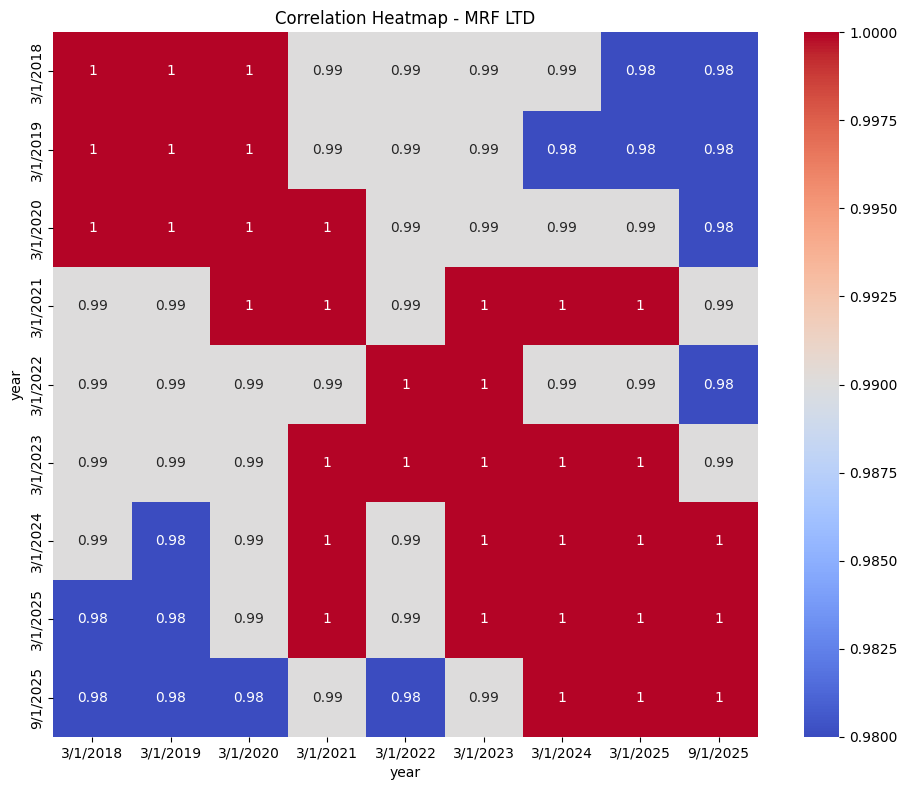

In [ ]:
# Dishant Sharma reg.no 12530084

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv(r"/content/MRF_balance.csv")
df = df.replace(',', '', regex=True)

df.set_index(df.columns[0], inplace=True)

df = df.apply(pd.to_numeric, errors='coerce')
df = df.T

print(df.head())

corr = df.corr().round(2)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', square=True)

plt.title("Correlation Heatmap - MRF LTD")
plt.tight_layout()
plt.show()

                            OLS Regression Results                            
Dep. Variable:            fixedassets   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                    nan
Method:                 Least Squares   F-statistic:                       nan
Date:                Fri, 08 May 2026   Prob (F-statistic):                nan
Time:                        19:39:49   Log-Likelihood:                 194.25
No. Observations:                   9   AIC:                            -370.5
Df Residuals:                       0   BIC:                            -368.7
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const              -35.1633        inf  

/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1795: RuntimeWarning: divide by zero encountered in divide
  return 1 - (np.divide(self.nobs - self.k_constant, self.df_resid)
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1795: RuntimeWarning: invalid value encountered in scalar multiply
  return 1 - (np.divide(self.nobs - self.k_constant, self.df_resid)
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1717: RuntimeWarning: divide by zero encountered in scalar divide
  return np.dot(wresid, wresid) / self.df_resid


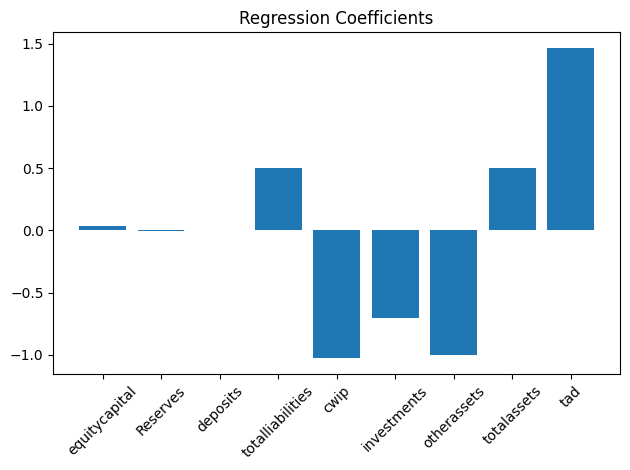

In [ ]:
# Dishant Sharma reg.no 12530084

import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

df = pd.read_csv(r"/content/MRF_balance.csv")
df.columns = df.columns.str.strip()

fa = [c for c in df.columns if "fixed" in c.lower() and "asset" in c.lower()][0]

y = df[fa]

x = df.select_dtypes("number").drop(columns=[fa], errors='ignore')

x = x.drop(columns=[c for c in x.columns if "other" in c.lower() and "liab" in c.lower()], errors='ignore')

model = sm.OLS(y, sm.add_constant(x), missing='drop').fit()

print(model.summary())

coef = model.params.drop("const", errors='ignore')

plt.bar(coef.index, coef.values)

plt.xticks(rotation=45)

plt.title("Regression Coefficients")

plt.tight_layout()

plt.show()

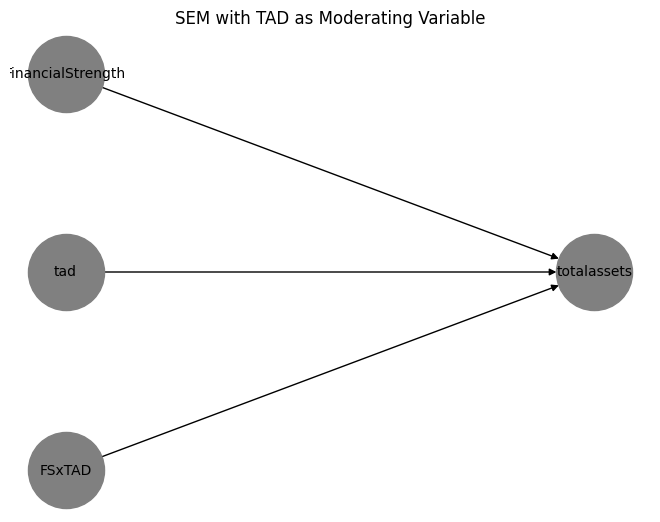

In [ ]:
# Dishant Sharma reg.no 12530084

import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

df = pd.read_csv(r"/content/MRF_balance.csv").dropna()

df = df.select_dtypes(include="number")

y = "totalassets"

moderator = "tad"

explanatory = [c for c in df.columns if c not in [y, moderator]]

df["FinancialStrength"] = df[explanatory].mean(axis=1)

df["FSxTAD"] = df["FinancialStrength"] * df[moderator]

G = nx.DiGraph()

G.add_edge("FinancialStrength", "totalassets")

G.add_edge("tad", "totalassets")

G.add_edge("FSxTAD", "totalassets")

pos = {
    "FinancialStrength": (0, 1),
    "tad": (0, 0),
    "FSxTAD": (0, -1),
    "totalassets": (2, 0)
}

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=3000,
    node_color="gray",
    font_size=10,
    arrows=True
)

plt.title("SEM with TAD as Moderating Variable")

plt.show()

R2 Score : 0.8443166844908733
RMSE     : 1394.00609754764


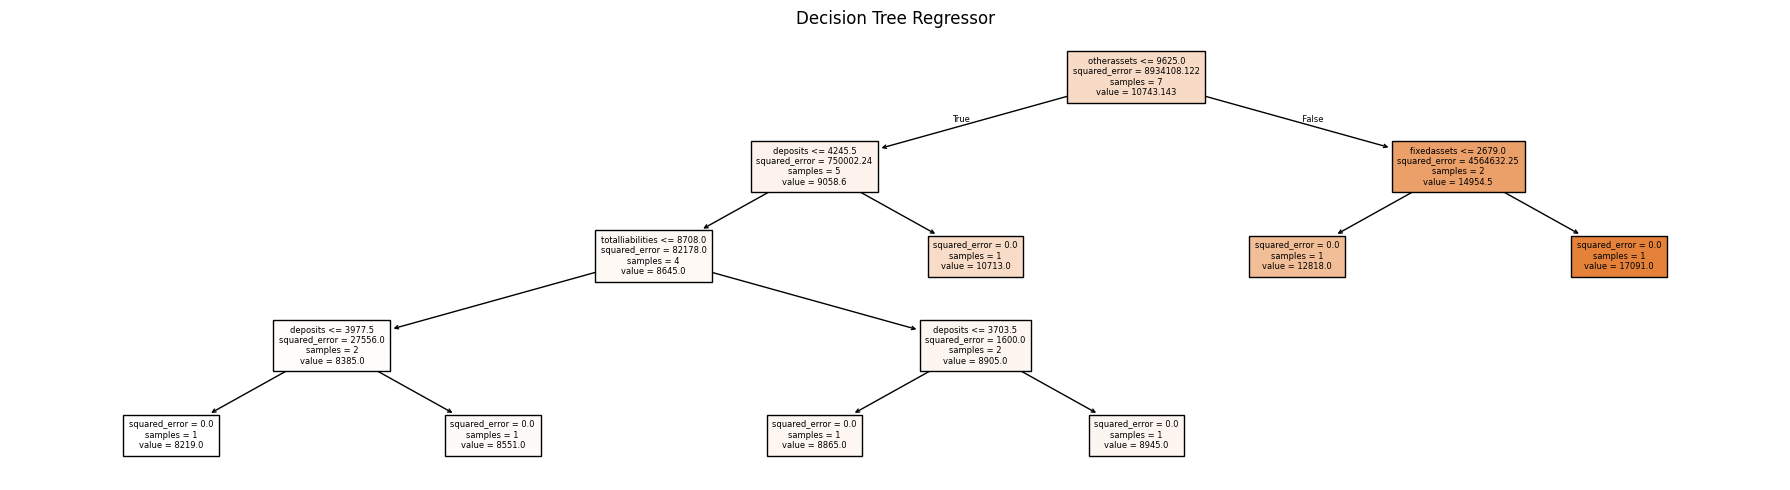

In [2]:
# Dishant Sharma reg.no 12530084
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from google.colab import files
import io

df = pd.read_csv(r"/content/MRF_balance.csv")

df = df.drop(columns=["year"])

X = df.drop(columns=["totalassets"])
y = df["totalassets"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = DecisionTreeRegressor(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("R2 Score :", r2_score(y_test, y_pred))
print("RMSE     :", mean_squared_error(y_test, y_pred) ** 0.5)

plt.figure(figsize=(18, 5))
plot_tree(model, feature_names=X.columns.tolist(), filled=True, fontsize=6)
plt.title("Decision Tree Regressor")
plt.tight_layout()
plt.show()